**Self organizing map for credit card fraud deection**

In [1]:
import numpy as np                           
import matplotlib.pyplot as plt  
import pandas as pd

In [16]:
%pip install minisom

Note: you may need to restart the kernel to use updated packages.


In [31]:
from minisom import MiniSom

In [32]:
from warnings import filterwarnings
filterwarnings ("ignore")

In [33]:
data = pd.read_csv("Credit_Card_Applications.csv")

In [34]:
data.head()

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [35]:
data.shape

(690, 16)

In [36]:
data.info

<bound method DataFrame.info of      CustomerID  A1     A2      A3  A4  A5  A6     A7  A8  A9  A10  A11  A12  \
0      15776156   1  22.08  11.460   2   4   4  1.585   0   0    0    1    2   
1      15739548   0  22.67   7.000   2   8   4  0.165   0   0    0    0    2   
2      15662854   0  29.58   1.750   1   4   4  1.250   0   0    0    1    2   
3      15687688   0  21.67  11.500   1   5   3  0.000   1   1   11    1    2   
4      15715750   1  20.17   8.170   2   6   4  1.960   1   1   14    0    2   
..          ...  ..    ...     ...  ..  ..  ..    ...  ..  ..  ...  ...  ...   
685    15808223   1  31.57  10.500   2  14   4  6.500   1   0    0    0    2   
686    15769980   1  20.67   0.415   2   8   4  0.125   0   0    0    0    2   
687    15675450   0  18.83   9.540   2   6   4  0.085   1   0    0    0    2   
688    15776494   0  27.42  14.500   2  14   8  3.085   1   1    1    0    2   
689    15592412   1  41.00   0.040   2  10   4  0.040   0   1    1    0    1   

     A1

In [37]:
X = data.iloc[:, 1:14].values
y = data.iloc[:, -1].values

In [38]:
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.0,22.08,11.460,2.0,4.0,4.0,1.585,0.0,0.0,0.0,1.0,2.0,100.0
1,0.0,22.67,7.000,2.0,8.0,4.0,0.165,0.0,0.0,0.0,0.0,2.0,160.0
2,0.0,29.58,1.750,1.0,4.0,4.0,1.250,0.0,0.0,0.0,1.0,2.0,280.0
3,0.0,21.67,11.500,1.0,5.0,3.0,0.000,1.0,1.0,11.0,1.0,2.0,0.0
4,1.0,20.17,8.170,2.0,6.0,4.0,1.960,1.0,1.0,14.0,0.0,2.0,60.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,1.0,31.57,10.500,2.0,14.0,4.0,6.500,1.0,0.0,0.0,0.0,2.0,0.0
686,1.0,20.67,0.415,2.0,8.0,4.0,0.125,0.0,0.0,0.0,0.0,2.0,0.0
687,0.0,18.83,9.540,2.0,6.0,4.0,0.085,1.0,0.0,0.0,0.0,2.0,100.0
688,0.0,27.42,14.500,2.0,14.0,8.0,3.085,1.0,1.0,1.0,0.0,2.0,120.0


In [39]:
pd.DataFrame(y)

,0
0,0
1,0
2,0
3,1
4,1
...,...
685,1
686,0
687,1
688,1


In [40]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range=(0,1))
x=sc.fit_transform(X)

In [41]:
pd.DataFrame(x)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.0,0.125263,0.409286,0.5,0.230769,0.375,0.055614,0.0,0.0,0.000000,1.0,0.5,0.05
1,0.0,0.134135,0.250000,0.5,0.538462,0.375,0.005789,0.0,0.0,0.000000,0.0,0.5,0.08
2,0.0,0.238045,0.062500,0.0,0.230769,0.375,0.043860,0.0,0.0,0.000000,1.0,0.5,0.14
3,0.0,0.119098,0.410714,0.0,0.307692,0.250,0.000000,1.0,1.0,0.164179,1.0,0.5,0.00
4,1.0,0.096541,0.291786,0.5,0.384615,0.375,0.068772,1.0,1.0,0.208955,0.0,0.5,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,1.0,0.267970,0.375000,0.5,1.000000,0.375,0.228070,1.0,0.0,0.000000,0.0,0.5,0.00
686,1.0,0.104060,0.014821,0.5,0.538462,0.375,0.004386,0.0,0.0,0.000000,0.0,0.5,0.00
687,0.0,0.076391,0.340714,0.5,0.384615,0.375,0.002982,1.0,0.0,0.000000,0.0,0.5,0.05
688,0.0,0.205564,0.517857,0.5,1.000000,0.875,0.108246,1.0,1.0,0.014925,0.0,0.5,0.06


In [42]:
som_grid_rows = 10
som_grid_columns = 10
iterations = 20000
sigma = 1
learning_rate = 0.5

In [43]:
som = MiniSom(x=som_grid_rows, y=som_grid_columns, input_len=13, sigma=sigma, learning_rate=learning_rate)
som.random_weights_init(x)
som.train_random(x, iterations)

In [44]:
som.distance_map()

array([[0.15515233, 0.31512749, 0.48323666, 0.53815654, 0.28775679,
        0.41260259, 0.40786105, 0.29942739, 0.31102949, 0.19175967],
       [0.43098449, 0.69799946, 0.72928499, 0.94161634, 0.64151077,
        0.61366538, 0.79621252, 0.58295398, 0.61417173, 0.32784399],
       [0.55427045, 0.80050671, 0.76018745, 0.82960617, 0.75860323,
        0.69220203, 0.60765106, 0.66542272, 0.63331401, 0.35357314],
       [0.52552441, 0.63475751, 0.81509972, 0.83057188, 0.82244969,
        0.52881545, 0.59710414, 0.63240255, 0.48405741, 0.26434188],
       [0.3576341 , 0.78328491, 0.75318582, 0.86627595, 0.57656516,
        0.45773813, 0.66822894, 0.63355489, 0.54801242, 0.51018101],
       [0.39889338, 0.5809152 , 0.90980474, 0.68312533, 0.47315309,
        0.59495123, 0.67749147, 0.80505911, 0.58962663, 0.35875254],
       [0.38370438, 0.73346651, 1.        , 0.74147439, 0.75670069,
        0.89600555, 0.79605474, 0.72308727, 0.50243708, 0.28801   ],
       [0.4891457 , 0.96147659, 0.7145572

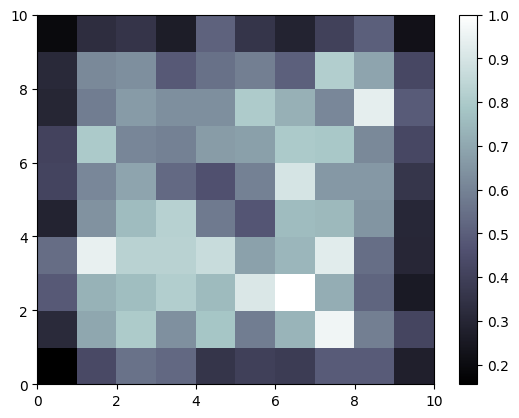

In [45]:
from pylab import plot, axis, show, pcolor, colorbar, bone
bone ()

pcolor(som.distance_map().T)
colorbar()
show()

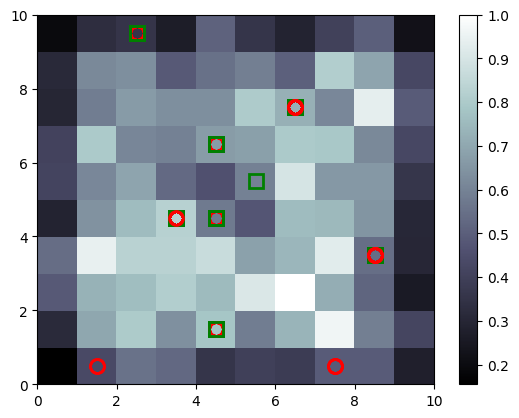

In [46]:
bone()
pcolor(som.distance_map().T)
colorbar() #gives legend

markers = ['o', 's']                       # if the observation is fraud then red circular color or else green square
colors = ['r', 'g']
for i, x in enumerate(X):
    w = som.winner(x)
    plot(w[0] + 0.5,
         w[1] + 0.5,
         markers[y[i]],
         markeredgecolor = colors[y[i]],
         markerfacecolor = 'None',
         markersize = 10,
         markeredgewidth = 2)
show()